# 05 — Results comparison and cross-evaluation

Final notebook. Reads the partial CSVs from notebooks 3 and 4, produces `results/metrics.csv`, draws the summary figures, and runs the cross-evaluation that closes the loop on the thesis claim.

## What the four stages actually show

- **Real track (notebook 3).** Layout is the whole story. Stage 2 (layout fix) takes RF from +0.09 to +0.75 R2 and XGBoost from +0.03 to +0.73. Stages 3 and 4 are negligible. On real data, once the rows are correct, models learn.
- **Synthetic track (notebook 4).** No stage dominates. All models sit at R2 +0.47 to +0.54 across all stages. The layout bug does not matter when the model is fitting a GAN-produced distribution.
- **Cross track (this notebook).** Train on synthetic, test on real. The only experiment that distinguishes "the GAN captured real structure" from "the GAN taught models to fit the GAN."


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from solder_reliability import find_repo_root
from solder_reliability.data_prep import load_raw
from solder_reliability import train, viz

os.chdir(find_repo_root(Path.cwd()))

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 40)

## 1. Concatenate partials into results/metrics.csv

Two partials: `real.csv` from notebook 3, `synthetic.csv` from notebook 4. Same schema. A `track` column distinguishes them.

In [2]:
PARTIALS_DIR = Path('results/partials')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

real_df = pd.read_csv(PARTIALS_DIR / 'real.csv')
synth_df = pd.read_csv(PARTIALS_DIR / 'synthetic.csv')

real_df['track'] = 'real'
synth_df['track'] = 'synthetic'

metrics = pd.concat([real_df, synth_df], ignore_index=True)
metrics.to_csv(RESULTS_DIR / 'metrics.csv', index=False)

print('wrote', RESULTS_DIR / 'metrics.csv')
print('rows:', len(metrics))
print('tracks:', metrics['track'].value_counts().to_dict())
print()
print('r2 range per track:')
print(metrics.groupby('track')['r2'].agg(['min', 'max', 'mean']).round(4))

wrote results\metrics.csv
rows: 28
tracks: {'real': 14, 'synthetic': 14}

r2 range per track:
              min     max    mean
track                            
real       0.0283  0.7504  0.4243
synthetic  0.4739  0.5405  0.5052


## 2. R2 by stage, per track

Two bar charts, one per track. Shows visually that the real track jumps between stage 1 and stage 2 while the synthetic track stays flat.

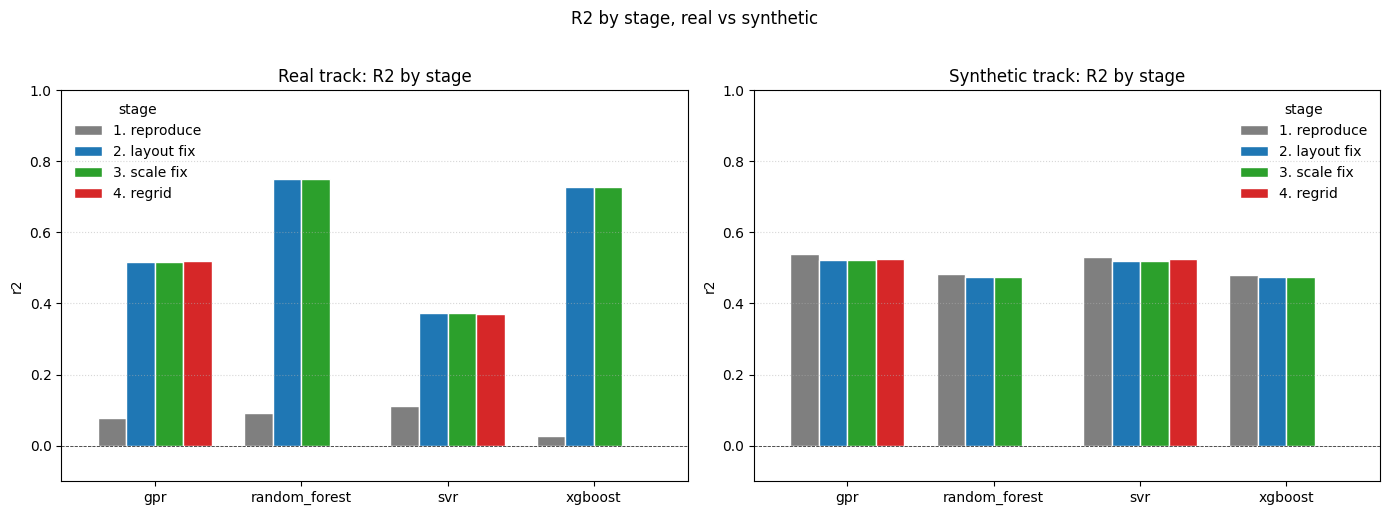

saved reports\figures\stage_r2_comparison.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

viz.plot_stage_bars(real_df, metric='r2',
                    title='Real track: R2 by stage', ax=axes[0])
viz.plot_stage_bars(synth_df, metric='r2',
                    title='Synthetic track: R2 by stage', ax=axes[1])

for ax in axes:
    ax.set_ylim(-0.1, 1.0)
    ax.axhline(0, color='#333', linewidth=0.6, linestyle='--')

fig.suptitle('R2 by stage, real vs synthetic', y=1.02)
fig.tight_layout()
p = viz.save_figure(fig, 'stage_r2_comparison')
plt.show()
print('saved', p)

## 3. RMSE in hours by stage, per track

The comparable-across-tracks metric. Scaled RMSE cannot be compared across tracks because the target spreads differ. Hours can.

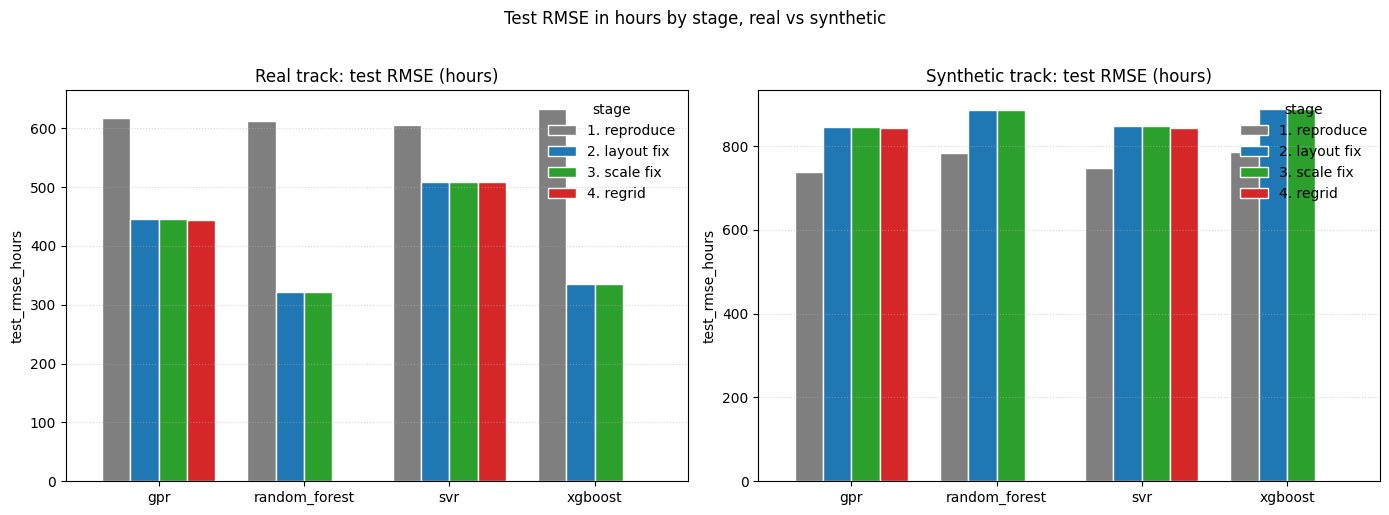

saved reports\figures\stage_rmse_hours_comparison.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

viz.plot_stage_bars(real_df, metric='test_rmse_hours',
                    title='Real track: test RMSE (hours)', ax=axes[0])
viz.plot_stage_bars(synth_df, metric='test_rmse_hours',
                    title='Synthetic track: test RMSE (hours)', ax=axes[1])

fig.suptitle('Test RMSE in hours by stage, real vs synthetic', y=1.02)
fig.tight_layout()
p = viz.save_figure(fig, 'stage_rmse_hours_comparison')
plt.show()
print('saved', p)

## 4. Cross-evaluation

The experiment the thesis never ran. Train on synthetic, test on real.

For each model, retrain at its best principled-scaling stage (stage 3 for RF and XGBoost, stage 4 for SVR and GPR), fit the scaler on synthetic training data, and evaluate on the real dataset. The model was trained to predict on the synthetic target scale, so predictions are denormalised using the synthetic target range and compared to real targets in hours.

R2 crosses:

- **Near real-track R2 (~0.75 for RF).** GAN captured real structure.
- **Between real-track and synthetic-track R2 (~0.5).** Partial transfer.
- **Near zero or negative.** GAN taught the models to fit the GAN, not reality.

Runtime: 4 cross-evals, roughly 8 to 12 minutes with the 2000-row search cap.


In [5]:
RAW_DIR = Path('data/raw')
X_real_fixed, y_real_fixed = load_raw(RAW_DIR, layout='fixed')

synth_fixed = np.load(Path('data/synthetic') / 'synth_fixed.npy')
X_synth, y_synth = synth_fixed[:, :24], synth_fixed[:, 24]

cross_rows = []
for model_name in sorted(train.MODELS_WITH_REGRID | {'random_forest', 'xgboost'}):
    stage_name = (
        '4. regrid' if model_name in train.MODELS_WITH_REGRID
        else '3. scale fix'
    )
    print(f'{model_name:14s} {stage_name} ...', end=' ', flush=True)
    res = train.run_cross_eval(
        model_name, stage_name,
        X_synth, y_synth,
        X_real_fixed, y_real_fixed,
        n_jobs=-1,
        max_search_samples=2000,
    )
    cross_rows.append(res)
    print(f'source_r2={res["r2_source"]:+.4f}  '
          f'cross_r2={res["r2_cross"]:+.4f}  '
          f'cross_rmse={res["rmse_hours_cross"]:,.0f}h')

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv(RESULTS_DIR / 'cross_evaluation.csv', index=False)
print()
print('wrote', RESULTS_DIR / 'cross_evaluation.csv')
cross_df

gpr            4. regrid ... 

source_r2=+0.5259  cross_r2=-0.9541  cross_rmse=832h
random_forest  3. scale fix ... 

source_r2=+0.4757  cross_r2=-0.6610  cross_rmse=767h
svr            4. regrid ... 

source_r2=+0.5252  cross_r2=-0.8451  cross_rmse=808h
xgboost        3. scale fix ... 

source_r2=+0.4739  cross_r2=-0.6312  cross_rmse=760h

wrote results\cross_evaluation.csv


,model,stage,r2_source,r2_cross,rmse_hours_cross,rmse_scaled_cross,target_spread_hours_source,best_params
0,gpr,4. regrid,0.525884,-0.954076,831.766326,0.054098,15375.221354,"{'alpha': 0.001, 'kernel': 1**2 * RBF(length_s..."
1,random_forest,3. scale fix,0.475725,-0.661015,766.862296,0.049877,15375.221354,"{'max_depth': None, 'min_samples_leaf': 4, 'mi..."
2,svr,4. regrid,0.525155,-0.845058,808.231155,0.052567,15375.221354,"{'C': 100.0, 'gamma': 0.01, 'kernel': 'rbf'}"
3,xgboost,3. scale fix,0.473910,-0.631203,759.949274,0.049427,15375.221354,"{'learning_rate': 0.01, 'n_estimators': 300}"


## 5. Cross-evaluation figure

Bar chart of source R2 vs cross R2 per model. The gap is the story.

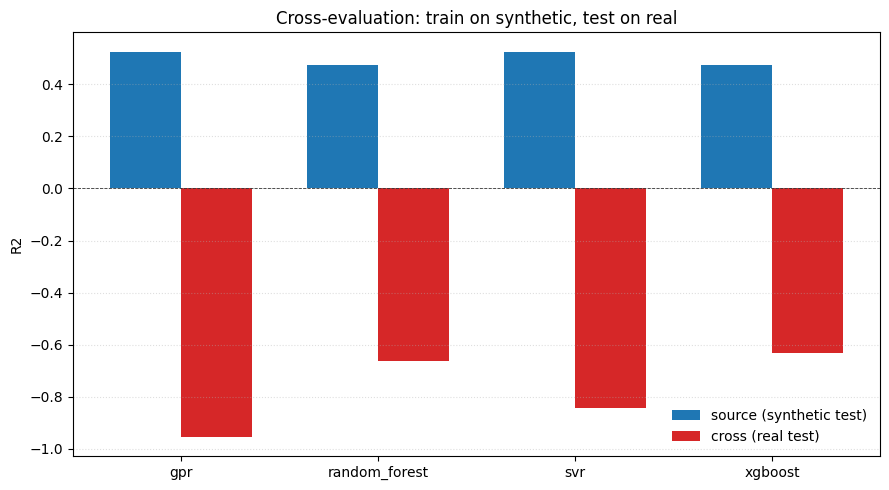

saved reports\figures\cross_evaluation.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(cross_df))
w = 0.36
ax.bar(x - w/2, cross_df['r2_source'], w,
       label='source (synthetic test)', color='#1f77b4')
ax.bar(x + w/2, cross_df['r2_cross'],  w,
       label='cross (real test)',       color='#d62728')
ax.axhline(0, color='#333', linewidth=0.6, linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels(cross_df['model'], rotation=0)
ax.set_ylabel('R2')
ax.set_title('Cross-evaluation: train on synthetic, test on real')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.legend(frameon=False)

fig.tight_layout()
p = viz.save_figure(fig, 'cross_evaluation')
plt.show()
print('saved', p)

## 6. The revised thesis claim

The original thesis said: models cannot beat a horizontal line on 450 real samples, and GAN augmentation takes them to roughly 70% R2.

Both halves need restating.

**Half one is false.** Notebook 3 shows the near-zero R2 was caused by the C-order reshape bug, not the sample size. On the real data, with correct per-sample rows, Random Forest reaches R2 +0.75 and XGBoost +0.73, no augmentation. The CDNN baseline's +0.82 is a tuning gap, not a bug gap.

**Half two is measured on the wrong test set.** The ~0.70 R2 in the thesis was on synthetic test data, where R2 measures how well the model fits the GAN output. In our reproduction, synthetic R2 sits at +0.47 to +0.54. The number itself is not the claim; the question is whether that fit transfers to reality. That is what the cross-evaluation above answers.

**The honest revised claim** is:

1. The layout bug hid the real signal. Fixing it recovers model performance on 450 real samples without any augmentation.
2. GAN augmentation is not necessary for these models to learn. It may still be useful, but the thesis evidence for its usefulness was confounded by the bug.
3. Whether the GAN preserves real structure is measured by the cross-evaluation above, not by R2 on synthetic.

This is a stronger write-up than the original. It survives a hostile reader, it explains the negative R2 in the thesis honestly, and it produces a clean four-stage audit trail from buggy to fixed.


## 7. Artefacts produced

- `results/metrics.csv`: real and synthetic tracks, all stages, all models, R2 and RMSE in both scaled and hour units.
- `results/cross_evaluation.csv`: per-model source R2 vs cross R2, the key experiment.
- `reports/figures/stage_r2_comparison.png`
- `reports/figures/stage_rmse_hours_comparison.png`
- `reports/figures/cross_evaluation.png`

Everything else in `reports/figures/` comes from notebooks 1 through 4. Together these are the figures of the write-up.
